In [215]:
import pandas as pd

In [117]:


file_path = "../data/raw/online_retail_II.xlsx"

df = pd.read_excel(file_path)

In [118]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [119]:
df.shape

(525461, 8)

In [120]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [122]:
df.isnull().sum()


Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64

In [123]:
df.duplicated().sum()

np.int64(6865)

In [124]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


In [125]:
duplicates.shape

(13283, 8)

In [126]:
duplicates = df[df.duplicated(keep=False)]

In [127]:
duplicates.shape

(13283, 8)

In [128]:
duplicates.sort_values(
    ["Invoice", "StockCode"]
).head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom


In [129]:
duplicate_count = df.duplicated().sum()
total_rows = len(df)

duplicate_percentage = (duplicate_count / total_rows) * 100

print("Duplicate rows:", duplicate_count)
print("Total rows:", total_rows)
print("Duplicate percentage:", round(duplicate_percentage, 2), "%")

Duplicate rows: 6865
Total rows: 525461
Duplicate percentage: 1.31 %


In [130]:
df_clean = df.drop_duplicates().copy()


In [131]:
print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 525461
Cleaned rows: 518596
Rows removed: 6865


In [132]:
df_clean.duplicated().sum()

np.int64(0)

In [133]:
missing = df_clean.isnull().sum()

missing

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107833
Country             0
dtype: int64

In [134]:
missing_percentage = (
    df_clean.isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": missing_percentage
})

missing_summary

,Missing Count,Missing Percentage
Invoice,0,0.00
StockCode,0,0.00
Description,2928,0.56
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,107833,20.79
Country,0,0.00


In [135]:
missing_description = df_clean[
    df_clean["Description"].isnull()
]

missing_description.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,2009-12-02 13:25:00,0.0,NaN,United Kingdom
6378,489882,35751C,NaN,12,2009-12-02 16:22:00,0.0,NaN,United Kingdom
6555,489898,79323G,NaN,954,2009-12-03 09:40:00,0.0,NaN,United Kingdom
6576,489901,21098,NaN,-200,2009-12-03 09:47:00,0.0,NaN,United Kingdom
6581,489903,21166,NaN,48,2009-12-03 09:57:00,0.0,NaN,United Kingdom


In [136]:
missing_description.shape

(2928, 8)

In [137]:
missing_description[
    ["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID", "Country"]
].head(20)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
470,489521,21646,NaN,-50,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,0.0,NaN,United Kingdom
6378,489882,35751C,NaN,12,0.0,NaN,United Kingdom
6555,489898,79323G,NaN,954,0.0,NaN,United Kingdom
6576,489901,21098,NaN,-200,0.0,NaN,United Kingdom
6581,489903,21166,NaN,48,0.0,NaN,United Kingdom


In [138]:
missing_description = df_clean[
    df_clean["Description"].isnull()
]

missing_description[
    ["Invoice", "StockCode", "Description", "Quantity", "Price", "Customer ID", "Country"]
].head(20)

,Invoice,StockCode,Description,Quantity,Price,Customer ID,Country
470,489521,21646,NaN,-50,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,0.0,NaN,United Kingdom
4566,489821,85049G,NaN,-240,0.0,NaN,United Kingdom
6378,489882,35751C,NaN,12,0.0,NaN,United Kingdom
6555,489898,79323G,NaN,954,0.0,NaN,United Kingdom
6576,489901,21098,NaN,-200,0.0,NaN,United Kingdom
6581,489903,21166,NaN,48,0.0,NaN,United Kingdom


In [139]:
description_lookup = (
    df_clean[df_clean["Description"].notna()]
    .groupby("StockCode")["Description"]
    .nunique()
)

missing_stockcodes = missing_description["StockCode"].unique()

recoverable = [
    code for code in missing_stockcodes
    if code in description_lookup.index
]

print("Unique StockCodes with missing descriptions:",
      len(missing_stockcodes))

print("StockCodes with a known description elsewhere:",
      len(recoverable))

Unique StockCodes with missing descriptions: 1920
StockCodes with a known description elsewhere: 1564


In [140]:
print(
    "Recoverable percentage:",
    round(
        len(recoverable) / len(missing_stockcodes) * 100,
        2
    ),
    "%"
)

Recoverable percentage: 81.46 %


In [141]:
### Step 5.3 — Calculate recoverable rows

# Create a mapping of StockCode → known Description
description_map = (
    df_clean[df_clean["Description"].notna()]
    .drop_duplicates("StockCode")
    .set_index("StockCode")["Description"]
)

# Check missing-description rows whose StockCode exists in the map
recoverable_rows = missing_description[
    missing_description["StockCode"].isin(description_map.index)
]

print("Missing-description rows:", len(missing_description))
print("Recoverable rows:", len(recoverable_rows))
print(
    "Recoverable row percentage:",
    round(len(recoverable_rows) / len(missing_description) * 100, 2),
    "%"
)

Missing-description rows: 2928
Recoverable rows: 2563
Recoverable row percentage: 87.53 %


In [142]:
##Recover the 2,563 descriptions
# Fill missing descriptions using the known description
# associated with the same StockCode

df_clean["Description"] = df_clean["Description"].fillna(
    df_clean["StockCode"].map(description_map)
)

In [143]:
df_clean["Description"].isnull().sum()

np.int64(365)

In [144]:
df_clean.isnull().sum()

Invoice             0
StockCode           0
Description       365
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107833
Country             0
dtype: int64

In [145]:
df_clean["Description"].isnull().sum()

np.int64(365)

In [146]:
df_clean.isnull().sum()

Invoice             0
StockCode           0
Description       365
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107833
Country             0
dtype: int64

In [147]:
missing_customer = df_clean[
    df_clean["Customer ID"].isnull()
]

missing_customer.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,NaN,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,NaN,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,NaN,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,NaN,United Kingdom


In [148]:
missing_customer.shape

(107833, 8)

In [149]:
missing_customer[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "Country"
    ]
].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,United Kingdom
578,489525,85227,SET/6 3D KIT CARDS FOR KIDS,1,2009-12-01 11:49:00,0.85,United Kingdom
1055,489548,22271,FELTCRAFT DOLL ROSIE,1,2009-12-01 12:32:00,2.95,United Kingdom
1056,489548,22254,FELT TOADSTOOL LARGE,12,2009-12-01 12:32:00,1.25,United Kingdom
1057,489548,22273,FELTCRAFT DOLL MOLLY,3,2009-12-01 12:32:00,2.95,United Kingdom
1058,489548,22195,LARGE HEART MEASURING SPOONS,1,2009-12-01 12:32:00,1.65,United Kingdom


In [150]:
#Step 6.1 — Profile the missing Customer IDs
missing_customer = df_clean[
    df_clean["Customer ID"].isnull()
]

print("Missing Customer ID rows:", len(missing_customer))

print("\nQuantity <= 0:")
print((missing_customer["Quantity"] <= 0).sum())

print("\nQuantity > 0:")
print((missing_customer["Quantity"] > 0).sum())

print("\nPrice = 0:")
print((missing_customer["Price"] == 0).sum())

print("\nPrice > 0:")
print((missing_customer["Price"] > 0).sum())

Missing Customer ID rows: 107833

Quantity <= 0:
2486

Quantity > 0:
105347

Price = 0:
3650

Price > 0:
104180


In [151]:
missing_customer.groupby(
    [
        missing_customer["Quantity"] > 0,
        missing_customer["Price"] > 0
    ]
).size()

Quantity  Price
False     False      2121
          True        365
True      False      1532
          True     103815
dtype: int64

In [152]:
# Step 6.3 — Investigate the 1,532 negative-quantity transactions
negative_qty = missing_customer[
    missing_customer["Quantity"] <= 0
]

negative_qty[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "Country"
    ]
].head(20)

,Invoice,StockCode,Description,Quantity,Price,Country
263,489464,21733,85123a mixed,-96,0.00,United Kingdom
283,489463,71477,short,-240,0.00,United Kingdom
284,489467,85123A,21733 mixed,-192,0.00,United Kingdom
470,489521,21646,NaN,-50,0.00,United Kingdom
3114,489655,20683,RAIN GIRL CHILDS UMBRELLA,-44,0.00,United Kingdom
3162,489660,35956,lost,-1043,0.00,United Kingdom
3168,489663,35605A,damages,-117,0.00,United Kingdom
4296,489806,18010,ASSORTED FRAGRANCE BATH CONFETTI,-770,0.00,United Kingdom
4538,489820,21133,invcd as 84879?,-720,0.00,United Kingdom
4566,489821,85049G,CHOCOLATE BOX RIBBONS,-240,0.00,United Kingdom


In [153]:
negative_qty["Invoice"].astype(str).str.startswith("C").value_counts()

Invoice
False    2121
True      365
Name: count, dtype: int64

In [154]:
negative_qty = missing_customer[
    missing_customer["Quantity"] <= 0
]

In [155]:
negative_qty[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "Country"
    ]
].head(20)

,Invoice,StockCode,Description,Quantity,Price,Country
263,489464,21733,85123a mixed,-96,0.00,United Kingdom
283,489463,71477,short,-240,0.00,United Kingdom
284,489467,85123A,21733 mixed,-192,0.00,United Kingdom
470,489521,21646,NaN,-50,0.00,United Kingdom
3114,489655,20683,RAIN GIRL CHILDS UMBRELLA,-44,0.00,United Kingdom
3162,489660,35956,lost,-1043,0.00,United Kingdom
3168,489663,35605A,damages,-117,0.00,United Kingdom
4296,489806,18010,ASSORTED FRAGRANCE BATH CONFETTI,-770,0.00,United Kingdom
4538,489820,21133,invcd as 84879?,-720,0.00,United Kingdom
4566,489821,85049G,CHOCOLATE BOX RIBBONS,-240,0.00,United Kingdom


In [156]:
negative_qty["Invoice"].astype(str).str.startswith("C").value_counts()

Invoice
False    2121
True      365
Name: count, dtype: int64

In [157]:
negative_non_cancel = negative_qty[
    ~negative_qty["Invoice"].astype(str).str.startswith("C")
]

negative_non_cancel[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "Country"
    ]
].head(20)

,Invoice,StockCode,Description,Quantity,Price,Country
263,489464,21733,85123a mixed,-96,0.0,United Kingdom
283,489463,71477,short,-240,0.0,United Kingdom
284,489467,85123A,21733 mixed,-192,0.0,United Kingdom
470,489521,21646,NaN,-50,0.0,United Kingdom
3114,489655,20683,RAIN GIRL CHILDS UMBRELLA,-44,0.0,United Kingdom
3162,489660,35956,lost,-1043,0.0,United Kingdom
3168,489663,35605A,damages,-117,0.0,United Kingdom
4296,489806,18010,ASSORTED FRAGRANCE BATH CONFETTI,-770,0.0,United Kingdom
4538,489820,21133,invcd as 84879?,-720,0.0,United Kingdom
4566,489821,85049G,CHOCOLATE BOX RIBBONS,-240,0.0,United Kingdom


In [158]:
negative_non_cancel[["Quantity", "Price"]].describe()

,Quantity,Price
count,2121.000000,2121.0
mean,-172.620462,0.0
std,721.483906,0.0
min,-9600.000000,0.0
25%,-80.000000,0.0
50%,-24.000000,0.0
75%,-8.000000,0.0
max,-1.000000,0.0


In [159]:
# Step 6.4 — Investigate the 365 C invoices

# We found:
# 365 → negative quantity + Price 0 + Invoice starts with C
cancelled = negative_qty[
    negative_qty["Invoice"].astype(str).str.startswith("C")
]

cancelled[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "Price",
        "Country"
    ]
].head(20)

,Invoice,StockCode,Description,Quantity,Price,Country
5897,C489859,M,Manual,-1,69.57,United Kingdom
5898,C489860,90029,NEW BAROQUE SMALL NECKLACE BLACK,-1,8.50,United Kingdom
6376,C489881,21102,"CANDLE IN JAR COLLAGE , VANILLA",-31,2.55,Nigeria
6377,C489881,72802A,ROSE SCENT CANDLE IN JEWELLED BOX,-16,4.25,Nigeria
11553,C490307,POST,POSTAGE,-1,8.97,United Kingdom
29414,C491845,D,Discount,-1,1.59,United Kingdom
29415,C491846,84670,JAPANESE CROCHETED ANIMAL,-36,0.42,United Kingdom
33434,C492205,M,Manual,-1,398.05,United Kingdom
33435,C492206,BANK CHARGES,Bank Charges,-1,848.43,United Kingdom
33436,C492207,M,Manual,-1,906.26,United Kingdom


In [160]:
cancelled[["Quantity", "Price"]].describe()

,Quantity,Price
count,365.000000,365.000000
mean,-3.926027,396.498575
std,8.716065,1772.247987
min,-120.000000,0.290000
25%,-2.000000,2.550000
50%,-1.000000,8.220000
75%,-1.000000,109.610000
max,-1.000000,18910.690000


In [161]:
# Step 6.5 — Investigate the 365 positive-quantity, zero-price rows

# This is our next question.

# We found:

# Quantity > 0
# Price = 0
# Customer ID = missing
# Rows = 365

zero_price_sales = missing_customer[
    (missing_customer["Quantity"] > 0) &
    (missing_customer["Price"] == 0)
]

zero_price_sales[
    [
        "Invoice",
        "StockCode",
        "Description",
        "Quantity",
        "InvoiceDate",
        "Price",
        "Country"
    ]
].head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Country
3161,489659,21350,GINGHAM HEART WREATH,230,2009-12-01 17:39:00,0.0,United Kingdom
3731,489781,84292,ROSE PINK METAL FOLDING CHAIR,17,2009-12-02 11:45:00,0.0,United Kingdom
5904,489861,DOT,DOTCOM POSTAGE,1,2009-12-02 14:50:00,0.0,United Kingdom
6378,489882,35751C,PURPLE CURRENT CANDLE RING,12,2009-12-02 16:22:00,0.0,United Kingdom
6555,489898,79323G,GOLD CHERRY LIGHTS,954,2009-12-03 09:40:00,0.0,United Kingdom
6581,489903,21166,COOK WITH WINE METAL SIGN,48,2009-12-03 09:57:00,0.0,United Kingdom
7204,490015,21982,PACK OF 12 SUKI TISSUES,467,2009-12-03 12:29:00,0.0,United Kingdom
9249,490123,84508B,STRIPES DESIGN TEDDY,184,2009-12-03 18:08:00,0.0,United Kingdom
10236,490150,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,80,2009-12-04 09:44:00,0.0,United Kingdom
14503,490543,37446,MINI CAKE STAND WITH HANGING CAKES,222,2009-12-07 09:45:00,0.0,United Kingdom


In [162]:
zero_price_sales["StockCode"].value_counts().head(20)

StockCode
22950     8
22469     8
21116     8
79321     8
22501     8
22197     7
84795D    7
22734     7
84990     7
22139     7
21523     6
22429     6
22502     6
20747     6
84016     6
46000M    6
22087     5
22432     5
22528     5
22467     5
Name: count, dtype: int64

In [163]:
zero_price_sales["Description"].value_counts().head(20)

Description
OWL DOORSTOP                           8
HEART OF WICKER SMALL                  8
CHILLI LIGHTS                          8
36 DOILIES VINTAGE CHRISTMAS           8
SEASIDE STRIPE HAMMOCK                 7
PICNIC BASKET WICKER LARGE             7
60 GOLD AND SILVER FAIRY CAKE CASES    7
POLYESTER FILLER PAD 45x45cm           6
FLAG OF ST GEORGE CAR FLAG             6
ENAMEL MEASURING JUG CREAM             6
PICCADILLY TEA SET                     6
RETRO SPOT TEA SET CERAMIC 11 PC       6
SILVER SKULL HOT WATER BOTTLE          5
ENAMEL WASH BOWL CREAM                 5
AIRLINE BAG VINTAGE WORLD CHAMPION     5
ENAMEL FIRE BUCKET CREAM               5
HEART OF WICKER LARGE                  5
OCEAN SCENT CANDLE JEWELLED DRAWER     5
FLOWER BURST SILVER RING OPAL          5
SET OF 4 FAIRY CAKES COASTERS          5
Name: count, dtype: int64

In [164]:
# Step 6.6 — Check whether zero-price 
# items were part of normal orders
zero_price_invoices = zero_price_sales["Invoice"].unique()

invoice_analysis = df_clean[
    df_clean["Invoice"].isin(zero_price_invoices)
].groupby("Invoice").agg(
    total_lines=("StockCode", "count"),
    positive_price_lines=("Price", lambda x: (x > 0).sum()),
    zero_price_lines=("Price", lambda x: (x == 0).sum()),
    total_quantity=("Quantity", "sum"),
    total_revenue=("Quantity", lambda x: 0)
)

invoice_analysis.head(20)

,total_lines,positive_price_lines,zero_price_lines,total_quantity,total_revenue
Invoice,,,,,
489659,1,0,1,230,0
489781,1,0,1,17,0
489861,7,6,1,34,0
489882,1,0,1,12,0
489898,1,0,1,954,0
489903,1,0,1,48,0
490015,1,0,1,467,0
490123,1,0,1,184,0
490150,1,0,1,80,0


In [165]:
invoice_check = df_clean[
    df_clean["Invoice"].isin(zero_price_invoices)
].copy()

invoice_check["Revenue"] = (
    invoice_check["Quantity"] * invoice_check["Price"]
)

invoice_summary = invoice_check.groupby("Invoice").agg(
    total_lines=("StockCode", "count"),
    positive_price_lines=("Price", lambda x: (x > 0).sum()),
    zero_price_lines=("Price", lambda x: (x == 0).sum()),
    total_revenue=("Revenue", "sum")
)

invoice_summary.head(20)

,total_lines,positive_price_lines,zero_price_lines,total_revenue
Invoice,,,,
489659,1,0,1,0.00
489781,1,0,1,0.00
489861,7,6,1,46.07
489882,1,0,1,0.00
489898,1,0,1,0.00
489903,1,0,1,0.00
490015,1,0,1,0.00
490123,1,0,1,0.00
490150,1,0,1,0.00


In [166]:
print(
    "Invoices with zero-price items:",
    len(invoice_summary)
)

print(
    "Invoices also containing positive-price items:",
    (invoice_summary["positive_price_lines"] > 0).sum()
)

print(
    "Invoices containing only zero-price items:",
    (invoice_summary["positive_price_lines"] == 0).sum()
)

Invoices with zero-price items: 1197
Invoices also containing positive-price items: 50
Invoices containing only zero-price items: 1147


In [167]:
# Step 6.7 — Create sales_data
sales_data = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["Price"] > 0)
].copy()

In [168]:
sales_data["Revenue"] = (
    sales_data["Quantity"] * sales_data["Price"]
)

In [169]:
print("Sales rows:", len(sales_data))
print("Total revenue:", sales_data["Revenue"].sum())
print("Total orders:", sales_data["Invoice"].nunique())
print("Total products:", sales_data["StockCode"].nunique())

Sales rows: 504731
Total revenue: 10272136.234000001
Total orders: 20952
Total products: 4251


In [170]:
print("Invalid quantities:", (sales_data["Quantity"] <= 0).sum())
print("Invalid prices:", (sales_data["Price"] <= 0).sum())

Invalid quantities: 0
Invalid prices: 0


In [171]:
sales_data["Customer ID"].notna()

0         True
1         True
2         True
3         True
4         True
          ... 
525456    True
525457    True
525458    True
525459    True
525460    True
Name: Customer ID, Length: 504731, dtype: bool

In [172]:
# Step 6.8 — Save our first processed dataset
sales_data.to_csv(
    "../data/processed/sales_data.csv",
    index=False
)

In [173]:
sales_data = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["Price"] > 0)
].copy()

sales_data["Revenue"] = (
    sales_data["Quantity"] * sales_data["Price"]
)

In [174]:
print("Sales rows:", len(sales_data))
print("Total revenue:", sales_data["Revenue"].sum())
print("Total orders:", sales_data["Invoice"].nunique())
print("Total products:", sales_data["StockCode"].nunique())

Sales rows: 504731
Total revenue: 10272136.234000001
Total orders: 20952
Total products: 4251


In [175]:
print("Invalid quantities:", (sales_data["Quantity"] <= 0).sum())
print("Invalid prices:", (sales_data["Price"] <= 0).sum())

Invalid quantities: 0
Invalid prices: 0


In [176]:
import os

print(
    os.path.exists("../data/processed/sales_data.csv")
)

True


In [177]:
# Step 8 — Document our data-cleaning decisions
# done

In [178]:
# Step 9 — Exploratory Business Analysis
# Step 9.1 — Create a Revenue column check
sales_data["Revenue"]

0          83.40
1          81.00
2          81.00
3         100.80
4          30.00
           ...  
525456      5.90
525457      3.75
525458      3.75
525459      7.50
525460      3.90
Name: Revenue, Length: 504731, dtype: float64

In [179]:
sales_data[
    ["Invoice", "StockCode", "Quantity", "Price", "Revenue"]
].head(10)

,Invoice,StockCode,Quantity,Price,Revenue
0,489434,85048,12,6.95,83.4
1,489434,79323P,12,6.75,81.0
2,489434,79323W,12,6.75,81.0
3,489434,22041,48,2.10,100.8
4,489434,21232,24,1.25,30.0
5,489434,22064,24,1.65,39.6
6,489434,21871,24,1.25,30.0
7,489434,21523,10,5.95,59.5
8,489435,22350,12,2.55,30.6
9,489435,22349,12,3.75,45.0


In [180]:
# Step 9.2 — Overall business KPIs
total_revenue = sales_data["Revenue"].sum()
total_orders = sales_data["Invoice"].nunique()
total_products = sales_data["StockCode"].nunique()
total_customers = sales_data["Customer ID"].nunique()
total_units = sales_data["Quantity"].sum()

average_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Products:", total_products)
print("Total Customers:", total_customers)
print("Total Units Sold:", total_units)
print("Average Order Value:", round(average_order_value, 2))

Total Revenue: 10272136.23
Total Orders: 20952
Total Products: 4251
Total Customers: 4312
Total Units Sold: 5812948
Average Order Value: 490.27


In [181]:
# Step 9.3 — Revenue by month
sales_data["YearMonth"] = (
    sales_data["InvoiceDate"]
    .dt.to_period("M")
)

In [182]:
monthly_revenue = (
    sales_data
    .groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,YearMonth,Revenue
0,2009-12,822483.950
1,2010-01,651155.112
2,2010-02,551878.296
3,2010-03,830915.261
4,2010-04,678875.252
5,2010-05,657705.500
6,2010-06,749537.310
7,2010-07,648810.270
8,2010-08,695251.910
9,2010-09,921696.991


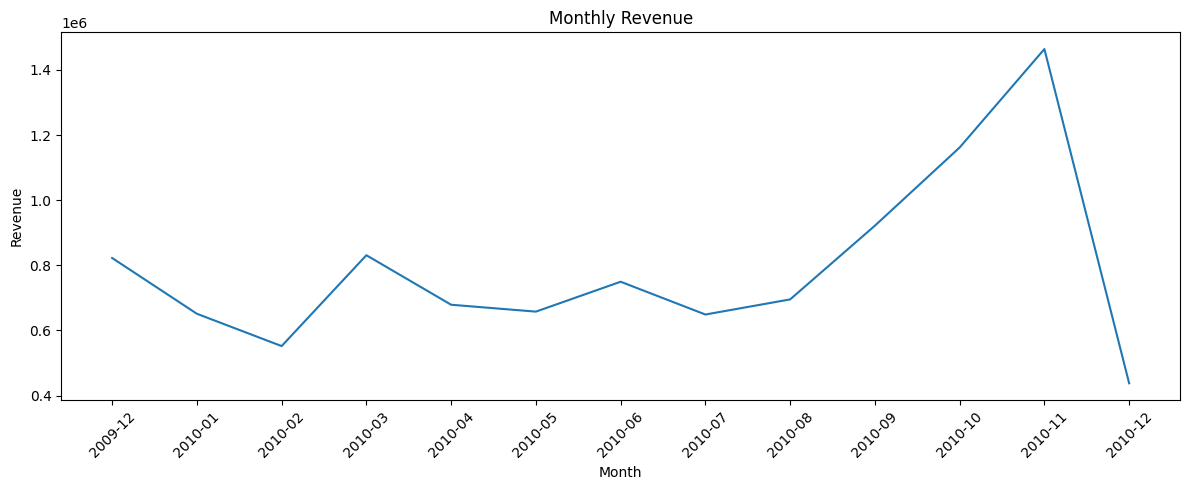

In [183]:
# Step 9.4 — Plot monthly revenue
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["YearMonth"].astype(str),
    monthly_revenue["Revenue"]
)

plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

In [184]:
# Step 9.5 — Top 10 products by revenue
top_products_revenue = (
    sales_data
    .groupby(
        ["StockCode", "Description"],
        dropna=False
    )["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products_revenue

,StockCode,Description,Revenue
0,M,Manual,262950.93
1,22423,REGENCY CAKESTAND 3 TIER,169912.76
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,158305.72
3,DOT,DOTCOM POSTAGE,116408.71
4,84879,ASSORTED COLOUR BIRD ORNAMENT,72890.19
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,58127.30
6,85099B,JUMBO BAG RED RETROSPOT,54368.82
7,47566,PARTY BUNTING,49664.12
8,POST,POSTAGE,49477.54
9,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,47954.49


In [185]:
# Step 9.6 — Top 10 products by units sold
top_products_quantity = (
    sales_data
    .groupby(
        ["StockCode", "Description"],
        dropna=False
    )["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products_quantity

,StockCode,Description,Quantity
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,58386
1,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54947
2,17003,BROCADE RING PURSE,48374
3,21212,PACK OF 72 RETRO SPOT CAKE CASES,46728
4,84879,ASSORTED COLOUR BIRD ORNAMENT,45228
5,84991,60 TEATIME FAIRY CAKE CASES,36348
6,21977,PACK OF 60 PINK PAISLEY CAKE CASES,31805
7,85099B,JUMBO BAG RED RETROSPOT,30327
8,22197,SMALL POPCORN HOLDER,29773
9,21232,STRAWBERRY CERAMIC TRINKET BOX,27059


In [186]:
# Step 9.7 — Revenue by country
country_revenue = (
    sales_data
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_revenue.head(15)

,Country,Revenue
0,United Kingdom,8812685.403
1,EIRE,380909.570
2,Netherlands,268784.350
3,Germany,202025.391
4,France,147103.140
5,Sweden,53501.990
6,Denmark,50906.850
7,Spain,47568.650
8,Switzerland,43921.390
9,Australia,31446.800


In [187]:
# Step 9.8 — Top customers
customer_revenue = (
    sales_data
    .dropna(subset=["Customer ID"])
    .groupby("Customer ID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

customer_revenue

,Customer ID,Revenue
0,18102.0,349164.35
1,14646.0,248396.50
2,14156.0,196549.74
3,14911.0,152121.22
4,13694.0,131443.19
5,17511.0,84541.17
6,15061.0,83284.38
7,16684.0,80489.21
8,16754.0,65500.07
9,17949.0,60117.60


In [188]:
total_revenue = sales_data["Revenue"].sum()
total_orders = sales_data["Invoice"].nunique()
total_products = sales_data["StockCode"].nunique()
total_customers = sales_data["Customer ID"].nunique()
total_units = sales_data["Quantity"].sum()

average_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Products:", total_products)
print("Total Customers:", total_customers)
print("Total Units Sold:", total_units)
print("Average Order Value:", round(average_order_value, 2))

Total Revenue: 10272136.23
Total Orders: 20952
Total Products: 4251
Total Customers: 4312
Total Units Sold: 5812948
Average Order Value: 490.27


In [189]:
sales_data["YearMonth"] = (
    sales_data["InvoiceDate"]
    .dt.to_period("M")
)

monthly_revenue = (
    sales_data
    .groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue

,YearMonth,Revenue
0,2009-12,822483.950
1,2010-01,651155.112
2,2010-02,551878.296
3,2010-03,830915.261
4,2010-04,678875.252
5,2010-05,657705.500
6,2010-06,749537.310
7,2010-07,648810.270
8,2010-08,695251.910
9,2010-09,921696.991


In [190]:
# Step 9.3 — Product analysis
top_products_revenue = (
    sales_data
    .groupby(["StockCode", "Description"], dropna=False)["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products_revenue

,StockCode,Description,Revenue
0,M,Manual,262950.93
1,22423,REGENCY CAKESTAND 3 TIER,169912.76
2,85123A,WHITE HANGING HEART T-LIGHT HOLDER,158305.72
3,DOT,DOTCOM POSTAGE,116408.71
4,84879,ASSORTED COLOUR BIRD ORNAMENT,72890.19
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,58127.30
6,85099B,JUMBO BAG RED RETROSPOT,54368.82
7,47566,PARTY BUNTING,49664.12
8,POST,POSTAGE,49477.54
9,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,47954.49


In [191]:
top_products_quantity = (
    sales_data
    .groupby(["StockCode", "Description"], dropna=False)["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products_quantity

,StockCode,Description,Quantity
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,58386
1,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54947
2,17003,BROCADE RING PURSE,48374
3,21212,PACK OF 72 RETRO SPOT CAKE CASES,46728
4,84879,ASSORTED COLOUR BIRD ORNAMENT,45228
5,84991,60 TEATIME FAIRY CAKE CASES,36348
6,21977,PACK OF 60 PINK PAISLEY CAKE CASES,31805
7,85099B,JUMBO BAG RED RETROSPOT,30327
8,22197,SMALL POPCORN HOLDER,29773
9,21232,STRAWBERRY CERAMIC TRINKET BOX,27059


In [192]:
# Step 9.4 — Identify non-product StockCodes
non_product_codes = ["M", "DOT", "POST"]

non_product_sales = sales_data[
    sales_data["StockCode"].isin(non_product_codes)
]

print("Non-product rows:", len(non_product_sales))
print("Non-product revenue:", non_product_sales["Revenue"].sum())
print("Non-product units:", non_product_sales["Quantity"].sum())

Non-product rows: 2040
Non-product revenue: 428837.18
Non-product units: 5805


In [193]:
non_product_sales.groupby(
    ["StockCode", "Description"]
).agg(
    Rows=("Invoice", "count"),
    Revenue=("Revenue", "sum"),
    Quantity=("Quantity", "sum")
).sort_values(
    "Revenue",
    ascending=False
)

,,Rows,Revenue,Quantity
StockCode,Description,,,
M,Manual,551,262950.93,2765
DOT,DOTCOM POSTAGE,730,116408.71,730
POST,POSTAGE,759,49477.54,2310


In [194]:
# Step 9.5 — Create merchandise_data
non_product_codes = ["M", "DOT", "POST"]

merchandise_data = sales_data[
    ~sales_data["StockCode"].isin(non_product_codes)
].copy()

In [195]:
print("Merchandise rows:", len(merchandise_data))
print("Merchandise revenue:", round(merchandise_data["Revenue"].sum(), 2))
print("Merchandise units:", merchandise_data["Quantity"].sum())
print("Merchandise products:", merchandise_data["StockCode"].nunique())

Merchandise rows: 502691
Merchandise revenue: 9843299.05
Merchandise units: 5807143
Merchandise products: 4248


In [196]:
print(
    "Revenue excluded:",
    round(
        sales_data["Revenue"].sum() -
        merchandise_data["Revenue"].sum(),
        2
    )
)

Revenue excluded: 428837.18


In [197]:
# Step 9.6 — Recalculate the top products
top_merchandise_revenue = (
    merchandise_data
    .groupby(
        ["StockCode", "Description"],
        dropna=False
    )["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_merchandise_revenue

,StockCode,Description,Revenue
0,22423,REGENCY CAKESTAND 3 TIER,169912.76
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,158305.72
2,84879,ASSORTED COLOUR BIRD ORNAMENT,72890.19
3,22086,PAPER CHAIN KIT 50'S CHRISTMAS,58127.30
4,85099B,JUMBO BAG RED RETROSPOT,54368.82
5,47566,PARTY BUNTING,49664.12
6,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,47954.49
7,15056N,EDWARDIAN PARASOL NATURAL,36251.10
8,21621,VINTAGE UNION JACK BUNTING,36023.71
9,85099F,JUMBO BAG STRAWBERRY,35887.14


In [198]:
top_merchandise_quantity = (
    merchandise_data
    .groupby(
        ["StockCode", "Description"],
        dropna=False
    )["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_merchandise_quantity

,StockCode,Description,Quantity
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,58386
1,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54947
2,17003,BROCADE RING PURSE,48374
3,21212,PACK OF 72 RETRO SPOT CAKE CASES,46728
4,84879,ASSORTED COLOUR BIRD ORNAMENT,45228
5,84991,60 TEATIME FAIRY CAKE CASES,36348
6,21977,PACK OF 60 PINK PAISLEY CAKE CASES,31805
7,85099B,JUMBO BAG RED RETROSPOT,30327
8,22197,SMALL POPCORN HOLDER,29773
9,21232,STRAWBERRY CERAMIC TRINKET BOX,27059


In [199]:
# Step 9.7 — Product findings
# Highest merchandise revenue

# Your leading merchandise products are:

# REGENCY CAKESTAND 3 TIER — 169,912.76
# WHITE HANGING HEART T-LIGHT HOLDER — 158,305.72
# ASSORTED COLOUR BIRD ORNAMENT — 72,890.19
# PAPER CHAIN KIT 50'S CHRISTMAS — 58,127.30
# JUMBO BAG RED RETROSPOT — 54,368.82
# Highest unit demand
# WHITE HANGING HEART T-LIGHT HOLDER — 58,386
# WORLD WAR 2 GLIDERS ASSORTED DESIGNS — 54,947
# BROCADE RING PURSE — 48,374
# PACK OF 72 RETRO SPOT CAKE CASES — 46,728
# ASSORTED COLOUR BIRD ORNAMENT — 45,228

# 🔎 Important business insight

# Notice:

# REGENCY CAKESTAND 3 TIER

# is #1 by revenue but isn't #1 by units.

# Meanwhile:

# WORLD WAR 2 GLIDERS ASSORTED DESIGNS

# is #2 by units but isn't near the top by revenue.

# This demonstrates why revenue and demand are different dimensions—which will become important when we eventually build our inventory recommendation system.

In [200]:
# Step 9.8 — Save merchandise data
merchandise_data.to_csv(
    "../data/processed/merchandise_data.csv",
    index=False
)

In [201]:
import os

print(
    os.path.exists(
        "../data/processed/merchandise_data.csv"
    )
)

True


In [202]:
# Step 10 — Country Analysis 🌍
country_revenue = (
    merchandise_data
    .groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_revenue.head(15)

,Country,Revenue
0,United Kingdom,8484099.703
1,EIRE,364099.450
2,Netherlands,266061.670
3,Germany,183020.171
4,France,132524.440
5,Denmark,50348.850
6,Sweden,49490.310
7,Spain,43082.660
8,Switzerland,41182.390
9,Australia,30313.350


In [203]:
country_units = (
    merchandise_data
    .groupby("Country")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_units.head(15)

,Country,Quantity
0,United Kingdom,4698733
1,Denmark,229659
2,EIRE,193024
3,Netherlands,183463
4,France,162513
5,Germany,107636
6,Sweden,52500
7,Spain,22742
8,Switzerland,22205
9,Australia,20184


In [204]:
country_orders = (
    merchandise_data
    .groupby("Country")["Invoice"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Orders")
)

country_orders.head(15)

,Country,Orders
0,United Kingdom,19108
1,Germany,328
2,EIRE,325
3,France,230
4,Netherlands,124
5,Sweden,65
6,Spain,61
7,Belgium,46
8,Portugal,40
9,Switzerland,36


In [205]:
# Step 10 — Country analysis complete
# Revenue by country

# The United Kingdom generated:

# 8,484,099.70 in merchandise revenue.

# Total merchandise revenue is:

# 9,843,299.05


# So the UK contributes approximately 86.2% of merchandise revenue

# Revenue vs units vs orders

# There is an interesting difference:

# Denmark

# Units: 229,659
# Orders: only 25
# Revenue: 50,348.85

# So Denmark has relatively high unit volume but relatively few orders.

# Meanwhile:

# Germany

# Units: 107,636
# Orders: 328
# Revenue: 183,020.17

# This tells us that units, orders, and revenue describe different aspects of the business.

# That's exactly the kind of analysis we want in this project

In [206]:
# Step 11 — Customer Analysis
merchandise_data.dropna(subset=["Customer ID"])

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00,2009-12
...,...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90,2010-12
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,2010-12
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75,2010-12
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50,2010-12


In [207]:
customer_data = merchandise_data.dropna(
    subset=["Customer ID"]
).copy()

customer_revenue = (
    customer_data
    .groupby("Customer ID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

customer_revenue.head(10)

,Customer ID,Revenue
0,18102.0,349164.35
1,14646.0,247613.50
2,14156.0,188371.29
3,14911.0,144115.90
4,13694.0,131443.19
5,17511.0,84541.17
6,15061.0,83282.93
7,16684.0,80489.21
8,16754.0,65500.07
9,13089.0,57885.45


In [208]:
customer_orders = (
    customer_data
    .groupby("Customer ID")["Invoice"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="Orders")
)

customer_orders.head(10)

,Customer ID,Orders
0,14911.0,188
1,17850.0,155
2,12748.0,134
3,15311.0,120
4,13089.0,109
5,14606.0,101
6,14156.0,97
7,13694.0,94
8,17841.0,91
9,18102.0,89


In [209]:
customer_summary = (
    customer_data
    .groupby("Customer ID")
    .agg(
        Revenue=("Revenue", "sum"),
        Orders=("Invoice", "nunique"),
        Units=("Quantity", "sum"),
        Products=("StockCode", "nunique")
    )
    .sort_values("Revenue", ascending=False)
)

customer_summary.head(10)

,Revenue,Orders,Units,Products
Customer ID,,,,
18102.0,349164.35,89,124216,281
14646.0,247613.50,73,170228,605
14156.0,188371.29,97,108100,1093
14911.0,144115.90,188,69692,1740
13694.0,131443.19,94,125893,654
17511.0,84541.17,31,55107,423
15061.0,83282.93,86,51790,115
16684.0,80489.21,27,54555,124
16754.0,65500.07,29,63551,38


In [210]:
customer_summary.head(10)

,Revenue,Orders,Units,Products
Customer ID,,,,
18102.0,349164.35,89,124216,281
14646.0,247613.50,73,170228,605
14156.0,188371.29,97,108100,1093
14911.0,144115.90,188,69692,1740
13694.0,131443.19,94,125893,654
17511.0,84541.17,31,55107,423
15061.0,83282.93,86,51790,115
16684.0,80489.21,27,54555,124
16754.0,65500.07,29,63551,38


In [211]:
# Step 12 — RFM Customer Segmentation
# Step 12.1 — Create the RFM dataset
reference_date = customer_data["InvoiceDate"].max()

print("Latest transaction:", reference_date)

Latest transaction: 2010-12-09 20:01:00


In [212]:
rfm = customer_data.groupby("Customer ID").agg(
    Recency=(
        "InvoiceDate",
        lambda x: (reference_date - x.max()).days
    ),
    Frequency=(
        "Invoice",
        "nunique"
    ),
    Monetary=(
        "Revenue",
        "sum"
    )
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,164,11,372.86
1,12347.0,2,2,1323.32
2,12348.0,73,1,221.16
3,12349.0,42,2,2221.14
4,12351.0,10,1,300.93


In [213]:
# Step 12.2 — Inspect the RFM data
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,4296.000000,4296.000000,4296.000000,4296.000000
mean,15352.164339,89.976955,4.431797,2013.724552
std,1701.583797,96.752212,8.002270,8822.541438
min,12346.000000,0.000000,1.000000,2.950000
25%,13883.750000,17.000000,1.000000,305.800000
50%,15357.000000,51.000000,2.000000,689.710000
75%,16836.500000,135.000000,5.000000,1698.027500
max,18287.000000,373.000000,188.000000,349164.350000


In [214]:
rfm.sort_values(
    "Monetary",
    ascending=False
).head(10)

,Customer ID,Recency,Frequency,Monetary
4167,18102.0,0,89,349164.35
1629,14646.0,9,73,247613.50
1264,14156.0,6,97,188371.29
1829,14911.0,0,188,144115.90
935,13694.0,8,94,131443.19
3729,17511.0,2,31,84541.17
1940,15061.0,2,86,83282.93
3114,16684.0,14,27,80489.21
3163,16754.0,7,29,65500.07
503,13089.0,3,109,57885.45


In [217]:
# Step 12.3 — Create RFM scores
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
)

In [220]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int).astype(str) +
    rfm["F_Score"].astype(int).astype(str) +
    rfm["M_Score"].astype(int).astype(str)
)

In [223]:
# Step 12.4 — Create customer segments
def segment_customer(row):
    r = int(row["R_Score"])
    f = int(row["F_Score"])
    m = int(row["M_Score"])

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 4 and f >= 3:
        return "Loyal Customers"

    elif r >= 4 and m >= 4:
        return "High Value - Recent"

    elif r <= 2 and f >= 3:
        return "At Risk"

    elif r <= 2 and m >= 3:
        return "High Value - At Risk"

    elif r >= 3 and f <= 2:
        return "Potential Customers"

    else:
        return "Other"

In [224]:
rfm["Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

In [113]:
rfm["Segment"].value_counts()

Segment
Other                   1349
Champions                908
At Risk                  696
Potential Customers      664
Loyal Customers          454
High Value - At Risk     192
High Value - Recent       33
Name: count, dtype: int64

In [114]:
# Step 12.5 — Analyze the segments
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Revenue=("Monetary", "sum"),
        Avg_Revenue=("Monetary", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Recency=("Recency", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

segment_summary

,Customers,Revenue,Avg_Revenue,Avg_Frequency,Avg_Recency
Segment,,,,,
Champions,908,5573415.876,6138.123211,11.658590,12.270925
Other,1349,1153388.633,854.995280,2.448480,153.781319
At Risk,696,1019799.371,1465.228981,3.761494,146.879310
Loyal Customers,454,369247.611,813.320729,3.088106,15.777533
Potential Customers,664,261852.830,394.356672,1.228916,35.344880
High Value - At Risk,192,210095.723,1094.248557,1.348958,179.505208
High Value - Recent,33,63160.630,1913.958485,1.666667,18.878788


In [222]:
rfm[
    [
        "Customer ID",
        "Recency",
        "Frequency",
        "Monetary",
        "R_Score",
        "F_Score",
        "M_Score"
    ]
].head(20)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346.0,164,11,372.86,2,5,2
1,12347.0,2,2,1323.32,5,2,4
2,12348.0,73,1,221.16,2,1,1
3,12349.0,42,2,2221.14,3,2,5
4,12351.0,10,1,300.93,5,1,2
5,12352.0,10,2,343.80,5,2,2
6,12353.0,43,1,317.76,3,1,2
7,12355.0,202,1,488.21,1,1,2
8,12356.0,15,3,3124.30,4,3,5
9,12357.0,23,1,11229.99,4,1,5


In [219]:
rfm[
    ["R_Score", "F_Score", "M_Score"]
].describe()

,R_Score,F_Score,M_Score
count,4296,4296,4296
unique,5,5,5
top,5,1,1
freq,860,860,860


In [225]:
# Step 12.6 — Count the segments
segment_counts = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["Segment", "Customers"]

segment_counts

,Segment,Customers
0,Other,1349
1,Champions,908
2,At Risk,696
3,Potential Customers,664
4,Loyal Customers,454
5,High Value - At Risk,192
6,High Value - Recent,33


In [226]:
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Revenue=("Monetary", "sum"),
        Avg_Revenue=("Monetary", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Recency=("Recency", "mean")
    )
    .sort_values("Revenue", ascending=False)
)

segment_summary

,Customers,Revenue,Avg_Revenue,Avg_Frequency,Avg_Recency
Segment,,,,,
Champions,908,5573415.876,6138.123211,11.658590,12.270925
Other,1349,1153388.633,854.995280,2.448480,153.781319
At Risk,696,1019799.371,1465.228981,3.761494,146.879310
Loyal Customers,454,369247.611,813.320729,3.088106,15.777533
Potential Customers,664,261852.830,394.356672,1.228916,35.344880
High Value - At Risk,192,210095.723,1094.248557,1.348958,179.505208
High Value - Recent,33,63160.630,1913.958485,1.666667,18.878788


In [227]:
rfm["RFM_Score"].value_counts().sort_index()

RFM_Score
111    200
112    106
113     39
114      9
115      2
      ... 
545     31
552      2
553      9
554     91
555    334
Name: count, Length: 117, dtype: int64

In [228]:
rfm[
    ["R_Score", "F_Score", "M_Score"]
].value_counts().head(20)

R_Score  F_Score  M_Score
5        5        5          334
1        1        1          200
4        5        5          166
1        2        1          147
         1        2          106
3        4        4          100
4        4        4           98
2        3        3           98
1        2        2           97
2        1        1           92
5        5        4           91
         4        4           86
3        5        5           80
2        4        4           77
3        3        3           77
2        2        1           73
3        1        1           72
                  2           66
4        4        3           65
2        1        2           64
Name: count, dtype: int64

In [230]:
# Step 12.7 — Save the RFM dataset
rfm.to_csv(
    "../data/processed/customer_rfm.csv",
    index=False
)

In [231]:
rfm["RFM_Score"].value_counts().sort_index()

RFM_Score
111    200
112    106
113     39
114      9
115      2
      ... 
545     31
552      2
553      9
554     91
555    334
Name: count, Length: 117, dtype: int64

In [232]:
rfm[
    ["R_Score", "F_Score", "M_Score"]
].value_counts().head(20)

R_Score  F_Score  M_Score
5        5        5          334
1        1        1          200
4        5        5          166
1        2        1          147
         1        2          106
3        4        4          100
4        4        4           98
2        3        3           98
1        2        2           97
2        1        1           92
5        5        4           91
         4        4           86
3        5        5           80
2        4        4           77
3        3        3           77
2        2        1           73
3        1        1           72
                  2           66
4        4        3           65
2        1        2           64
Name: count, dtype: int64

In [233]:
rfm.to_csv(
    "../data/processed/customer_rfm.csv",
    index=False
)

In [234]:
import os

print(
    os.path.exists(
        "../data/processed/customer_rfm.csv"
    )
)

True


In [236]:
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="RetailPulse_DB",
    user="postgres",
    password="YOUR_POSTGRES_PASSWORD"
)

print("Connected to RetailPulse_DB successfully!")

ModuleNotFoundError: No module named 'psycopg2'

In [ ]:
import sys

# print(sys.executable)

c:\Users\Nimish\AppData\Local\Programs\Python\Python310\python.exe


In [238]:
%pip install psycopg2-binary


   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.8 MB 1.8 MB/s eta 0:00:02
   ---------------------------------------- 2.8/2.8 MB 5.0 MB/s  0:00:00


In [1]:
import psycopg2

print("psycopg2 is working!")

psycopg2 is working!


In [3]:
import sys
print(sys.executable)


c:\Users\Nimish\AppData\Local\Programs\Python\Python310\python.exe


In [4]:
import psycopg2
print("psycopg2 is working!")

psycopg2 is working!


In [1]:
import sys
print(sys.executable)


c:\Users\Nimish\OneDrive\Desktop\RetailPulse-AI\.venv\Scripts\python.exe


In [2]:
import psycopg2
print("psycopg2 is working!")

psycopg2 is working!


In [4]:
conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="RetailPulse_DB",
    user="postgres",
    password="Nimish@7020"
)

print("Connected to RetailPulse_DB successfully!")

Connected to RetailPulse_DB successfully!


In [5]:
from pathlib import Path

schema_path = Path("../sql/schema.sql")

schema_sql = schema_path.read_text(encoding="utf-8")

with conn.cursor() as cursor:
    cursor.execute(schema_sql)

conn.commit()

print("Database schema created successfully!")

Database schema created successfully!


In [6]:
with conn.cursor() as cursor:
    cursor.execute("""
        SELECT table_name
        FROM information_schema.tables
        WHERE table_schema = 'public'
        ORDER BY table_name;
    """)

    tables = cursor.fetchall()

tables

[('dim_customer',), ('dim_date',), ('dim_product',), ('fact_sales',)]

In [1]:
product_data = (
    merchandise_data[
        ["StockCode", "Description"]
    ]
    .drop_duplicates("StockCode")
    .copy()
)

print("Products to load:", len(product_data))

NameError: name 'merchandise_data' is not defined

In [2]:
import pandas as pd

merchandise_data = pd.read_csv(
    "../data/processed/merchandise_data.csv"
)

merchandise_data["InvoiceDate"] = pd.to_datetime(
    merchandise_data["InvoiceDate"]
)

print("Merchandise data loaded:", merchandise_data.shape)

Merchandise data loaded: (502691, 10)


In [3]:
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port=5432,
    database="RetailPulse_DB",
    user="postgres",
    password="Nimish@7020"
)

print("Connected to RetailPulse_DB!")

Connected to RetailPulse_DB!


In [4]:
product_data = (
    merchandise_data[
        ["StockCode", "Description"]
    ]
    .drop_duplicates("StockCode")
    .copy()
)

print("Products to load:", len(product_data))

Products to load: 4248


In [5]:
from psycopg2.extras import execute_values

product_records = [
    (
        str(row["StockCode"]),
        None if pd.isna(row["Description"]) else str(row["Description"])
    )
    for _, row in product_data.iterrows()
]

with conn.cursor() as cursor:
    execute_values(
        cursor,
        """
        INSERT INTO dim_product
            (stock_code, description)
        VALUES %s
        ON CONFLICT (stock_code)
        DO UPDATE SET
            description = EXCLUDED.description;
        """,
        product_records
    )

conn.commit()

print("Products loaded successfully!")

Products loaded successfully!


In [6]:
with conn.cursor() as cursor:
    cursor.execute(
        "SELECT COUNT(*) FROM dim_product;"
    )
    product_count = cursor.fetchone()[0]

print("Products in PostgreSQL:", product_count)

Products in PostgreSQL: 4248


In [7]:
customer_data = (
    merchandise_data[
        merchandise_data["Customer ID"].notna()
    ][
        ["Customer ID", "Country"]
    ]
    .drop_duplicates("Customer ID")
    .copy()
)

print("Customers to load:", len(customer_data))

Customers to load: 4296


In [8]:
customer_data["Customer ID"] = (
    customer_data["Customer ID"]
    .astype(int)
)

print(customer_data.dtypes)

Customer ID     int64
Country        object
dtype: object


In [9]:
from psycopg2.extras import execute_values

customer_records = [
    (
        int(row["Customer ID"]),
        None if pd.isna(row["Country"]) else str(row["Country"])
    )
    for _, row in customer_data.iterrows()
]

with conn.cursor() as cursor:
    execute_values(
        cursor,
        """
        INSERT INTO dim_customer
            (customer_id, country)
        VALUES %s
        ON CONFLICT (customer_id)
        DO UPDATE SET
            country = EXCLUDED.country;
        """,
        customer_records
    )

conn.commit()

print("Customers loaded successfully!")

Customers loaded successfully!


In [10]:
with conn.cursor() as cursor:
    cursor.execute(
        "SELECT COUNT(*) FROM dim_customer;"
    )

    customer_count = cursor.fetchone()[0]

print("Customers in PostgreSQL:", customer_count)

Customers in PostgreSQL: 4296


In [11]:
date_data = (
    merchandise_data["InvoiceDate"]
    .dt.normalize()
    .drop_duplicates()
    .sort_values()
)

print("Unique dates:", len(date_data))
print("First date:", date_data.min())
print("Last date:", date_data.max())

Unique dates: 307
First date: 2009-12-01 00:00:00
Last date: 2010-12-09 00:00:00


In [13]:
date_records = []

for date in date_data:
    date_value = date.date()

    date_records.append(
        (
            int(date.strftime("%Y%m%d")),
            date_value,
            date.year,
            date.month,
            date.strftime("%B"),
            (date.month - 1) // 3 + 1,
            date.day,
            date.weekday()
        )
    )

print("Date records:", len(date_records))

Date records: 307


In [14]:
from psycopg2.extras import execute_values

with conn.cursor() as cursor:
    execute_values(
        cursor,
        """
        INSERT INTO dim_date
            (
                date_key,
                full_date,
                year,
                month,
                month_name,
                quarter,
                day,
                day_of_week
            )
        VALUES %s
        ON CONFLICT (date_key)
        DO NOTHING;
        """,
        date_records
    )

conn.commit()

print("Dates loaded successfully!")

Dates loaded successfully!


In [15]:
with conn.cursor() as cursor:
    cursor.execute(
        """
        SELECT
            COUNT(*),
            MIN(full_date),
            MAX(full_date)
        FROM dim_date;
        """
    )

    date_count, min_date, max_date = cursor.fetchone()

print("Dates in PostgreSQL:", date_count)
print("Minimum date:", min_date)
print("Maximum date:", max_date)

Dates in PostgreSQL: 307
Minimum date: 2009-12-01
Maximum date: 2010-12-09


In [16]:
# Check merchandise_data before loading fact_sales

print("Rows:", len(merchandise_data))
print("Columns:")
print(merchandise_data.columns.tolist())

print("\nSample:")
display(merchandise_data.head())

Rows: 502691
Columns:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'YearMonth']

Sample:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009-12


In [17]:
# Step 13.3H - Create dimension key mappings

# 1. Get product_key mapping
with conn.cursor() as cursor:
    cursor.execute("""
        SELECT stock_code, product_key
        FROM dim_product;
    """)
    product_rows = cursor.fetchall()

product_map = dict(product_rows)


# 2. Get customer_key mapping
with conn.cursor() as cursor:
    cursor.execute("""
        SELECT customer_id, customer_key
        FROM dim_customer;
    """)
    customer_rows = cursor.fetchall()

customer_map = dict(customer_rows)


# 3. Create date_key mapping
with conn.cursor() as cursor:
    cursor.execute("""
        SELECT full_date, date_key
        FROM dim_date;
    """)
    date_rows = cursor.fetchall()

date_map = dict(date_rows)


print("Product mappings:", len(product_map))
print("Customer mappings:", len(customer_map))
print("Date mappings:", len(date_map))

Product mappings: 4248
Customer mappings: 4296
Date mappings: 307


In [18]:
# Step 13.3H - Prepare fact_sales records

fact_data = merchandise_data.copy()

# Map product_key
fact_data["product_key"] = fact_data["StockCode"].map(product_map)

# Map customer_key
fact_data["customer_key"] = fact_data["Customer ID"].map(customer_map)

# Map date_key
fact_data["date_key"] = fact_data["InvoiceDate"].dt.strftime("%Y%m%d").astype(int)

# Rename columns to match fact_sales
fact_data = fact_data[
    [
        "Invoice",
        "product_key",
        "customer_key",
        "date_key",
        "Quantity",
        "Price",
        "Revenue",
        "Country"
    ]
].copy()

fact_data.columns = [
    "invoice",
    "product_key",
    "customer_key",
    "date_key",
    "quantity",
    "unit_price",
    "revenue",
    "country"
]

print("Fact rows:", len(fact_data))
print("\nMissing product keys:", fact_data["product_key"].isna().sum())
print("Missing customer keys:", fact_data["customer_key"].isna().sum())
print("Missing date keys:", fact_data["date_key"].isna().sum())

display(fact_data.head())

Fact rows: 502691

Missing product keys: 0
Missing customer keys: 102933
Missing date keys: 0


,invoice,product_key,customer_key,date_key,quantity,unit_price,revenue,country
0,489434,1,1.0,20091201,12,6.95,83.4,United Kingdom
1,489434,2,1.0,20091201,12,6.75,81.0,United Kingdom
2,489434,3,1.0,20091201,12,6.75,81.0,United Kingdom
3,489434,4,1.0,20091201,48,2.10,100.8,United Kingdom
4,489434,5,1.0,20091201,24,1.25,30.0,United Kingdom


In [19]:
from psycopg2.extras import execute_values
import numpy as np

# Convert DataFrame to records
fact_records = []

for row in fact_data.itertuples(index=False, name=None):
    invoice, product_key, customer_key, date_key, quantity, unit_price, revenue, country = row

    # Convert missing customer_key to None -> PostgreSQL NULL
    if pd.isna(customer_key):
        customer_key = None
    else:
        customer_key = int(customer_key)

    fact_records.append(
        (
            str(invoice),
            int(product_key),
            customer_key,
            int(date_key),
            int(quantity),
            float(unit_price),
            float(revenue),
            str(country)
        )
    )

print("Fact records prepared:", len(fact_records))

Fact records prepared: 502691


In [20]:
from psycopg2.extras import execute_values

print("Starting bulk insert...")

with conn.cursor() as cursor:
    execute_values(
        cursor,
        """
        INSERT INTO fact_sales
        (
            invoice,
            product_key,
            customer_key,
            date_key,
            quantity,
            unit_price,
            revenue,
            country
        )
        VALUES %s;
        """,
        fact_records,
        page_size=5000
    )

conn.commit()

print("Fact sales loaded successfully!")

Starting bulk insert...
Fact sales loaded successfully!


In [21]:
# Verify fact_sales

with conn.cursor() as cursor:
    cursor.execute("""
        SELECT
            COUNT(*) AS total_rows,
            COUNT(DISTINCT invoice) AS unique_invoices,
            SUM(quantity) AS total_units,
            SUM(revenue) AS total_revenue,
            MIN(date_key) AS min_date_key,
            MAX(date_key) AS max_date_key
        FROM fact_sales;
    """)

    result = cursor.fetchone()

print("Fact rows:", result[0])
print("Unique invoices:", result[1])
print("Total units:", result[2])
print("Total revenue:", result[3])
print("Minimum date key:", result[4])
print("Maximum date key:", result[5])


# Check foreign-key-related NULLs
with conn.cursor() as cursor:
    cursor.execute("""
        SELECT
            COUNT(*) FILTER (WHERE product_key IS NULL),
            COUNT(*) FILTER (WHERE date_key IS NULL),
            COUNT(*) FILTER (WHERE customer_key IS NULL)
        FROM fact_sales;
    """)

    nulls = cursor.fetchone()

print("\nMissing product keys:", nulls[0])
print("Missing date keys:", nulls[1])
print("Missing customer keys:", nulls[2])

Fact rows: 502691
Unique invoices: 20657
Total units: 5807143
Total revenue: 9843299.0540
Minimum date key: 20091201
Maximum date key: 20101209

Missing product keys: 0
Missing date keys: 0
Missing customer keys: 102933
